In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[1]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [15]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [16]:
from src.utils.montage_processing import *
filename_colors = r"../../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values
positions = get_topo_positions(CED_FILE)

In [17]:
import h5py
import os
folder = r"..\..\data\exp\datasets_offBCI"
filenames = os.listdir(folder)
filenames = np.asarray([filename for filename in filenames if filename.find("SOUND.mat") != -1])

def get_session_n(filename):
    return int(filename[filename.find("_")+1: filename.find("__")])
# filenames = np.asarray([filename for filename in filenames if get_session_n(filename) in session_dict.values()])
# print(session_dict.values())
# print(filenames)


In [18]:
def decode_matlab_string_payload(ds):
    arr = np.asarray(ds[()]).ravel().astype(np.uint64)

    ndims = int(arr[1])
    shape = tuple(int(x) for x in arr[2:2 + ndims])
    n_items = int(np.prod(shape))

    lengths_start = 2 + ndims
    lengths = [int(x) for x in arr[lengths_start:lengths_start + n_items]]
    packed = arr[lengths_start + n_items:]

    codes = []
    for value in packed:
        codes.extend(
            np.frombuffer(int(value).to_bytes(8, "little"), dtype="<u2").tolist()
        )

    strings = []
    pos = 0
    for length in lengths:
        strings.append("".join(chr(c) for c in codes[pos:pos + length]))
        pos += length

    return np.array(strings, dtype=object).reshape(shape, order="F")

def read_matlab_string(f, dataset_path):
    desc = np.asarray(f[dataset_path][()]).ravel()
    mcos_index = int(desc[4]) + 1
    ref = f["#subsystem#/MCOS"][()].ravel()[mcos_index]
    return decode_matlab_string_payload(f[ref])

def get_orig_name(fn):
    with h5py.File(fn, "r") as hdf:
        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()
        return orig[0]

fl_dict = {}
for filename in filenames:
    fl_dict[str(filename)] = get_orig_name(os.path.join(folder, filename))

def get_session_subject_corr(fl_dict):
    session_dict = {}
    for session, record in zip(fl_dict.keys(), fl_dict.values()):
        session_dict[record[record.find("_")+1:record.find("_")+5]] = session[session.find("_")+1:session.find("__")]
    return session_dict
session_dict = get_session_subject_corr(fl_dict)
session_dict

{'18EK': '102',
 '01AV': '63',
 '02NS': '65',
 '07IK': '71',
 '14AL': '77',
 '04KK': '79',
 '08EN': '80',
 '12VD': '88',
 '15SZ': '93',
 '19IT': '94',
 '05UB': '96'}

In [9]:
fn = os.path.join(folder, filenames[0])
def code_labels(labels, n):
    lab = np.zeros((n, 2))
    lab[np.where(labels == "hand"), 0] = 1
    lab[np.where(labels == "rest"), 1] = 1
    return lab  

def get_data(fn):
    with h5py.File(fn, "r") as hdf:
        tvec = hdf['cleanedResult/tvec'][:][0]
        epoch  = hdf['cleanedResult/epochs_clean'][:] 
        
        label = read_matlab_string(hdf, "cleanedResult/epoch_types")
        label = label.ravel(order="F").tolist()
        
        def get_label(stimulus):
            try:
                label = json.loads(stimulus)["stimulus"]
                return label
            except:
                pass
        labels = np.asarray([get_label(stimulus) for stimulus in label])
        lab = code_labels(labels, epoch.shape[1])

        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()
        return tvec, epoch, lab

In [128]:
subj = "01AV" 
cond = "offBCI" 
spot = "M1_AP"

def get_epochs(subj, cond, spot, filenames):
    session_id = session_dict[subj] 
    epochs = []
    labels = []
    for filename in [fn for fn in filenames if fn.find(str(session_id)) != -1]:
        orig = get_orig_name(os.path.join(folder, filename))
        if orig.find(cond) != -1: # and orig.find(spot) != -1:
            print("---", orig, "---", filename, "---")
            tvec, epoch, lab = get_data(os.path.join(folder, filename))
            epochs.append(epoch)
            labels.extend(lab)
    epochs = np.concat(epochs, axis=1)
    labels = np.asarray(labels)
    return epochs, labels, tvec

def baseline_correction(epoch, tvec, from_ms=-100, to_ms=-50):
    baseline = np.mean(epoch[:, np.where((tvec>=from_ms) & (tvec<=to_ms))])
    return epoch - baseline

from scipy.stats import trim_mean
def get_teps(labels, epochs, tvec):
    rest_mask = np.where(labels[:, 1] == 1)[0]
    mi_mask = np.where(labels[:, 0] == 1)[0]

    epochs_baseline_corr = np.asarray([baseline_correction(epochs[:, i, :], tvec) for i in range(epochs.shape[1])])
    epochs_baseline_corr = np.swapaxes(epochs_baseline_corr, 0, 1)

    TEPs_rest = trim_mean(epochs_baseline_corr[:, rest_mask, :], 0.1, axis=1 )
    TEPs_MI = trim_mean(epochs_baseline_corr[:, mi_mask,  :], 0.1, axis=1)
    return TEPs_rest, TEPs_MI

In [129]:
epochs[:, 0]

array([[ 34.245113 ,  33.368534 ,  32.74266  , ...,  13.867679 ,
         14.469185 ,  13.364065 ],
       [ 39.565517 ,  40.087116 ,  37.48487  , ...,  12.690158 ,
         11.156461 ,   8.706529 ],
       [ 21.265947 ,  19.726242 ,  23.059164 , ...,   6.414852 ,
          7.667115 ,   5.4168286],
       ...,
       [-18.469963 , -19.420963 , -19.113073 , ..., -26.92823  ,
        -28.79402  , -26.684156 ],
       [  9.874674 ,   6.9519715,   5.606452 , ...,  -2.9053526,
         -1.6067524,   1.2762983],
       [ -7.210751 ,  -6.7845716,  -8.299608 , ...,  -2.9270155,
         -2.5330858,  -5.968103 ]], shape=(64, 4001), dtype=float32)

## mean by subjects

In [130]:
TEPs_rest, TEPs_MI = [], []
for subj in session_dict.keys():
    epochs, labels, tvec  = get_epochs(subj, cond, spot, filenames)
    print(epochs.shape, labels.shape)
    rest, mi = get_teps(labels, epochs, tvec)
    TEPs_rest.append(rest)
    TEPs_MI.append(mi)

--- 11_18EK_M1_PA_34MSO_offBCI.hdf5 --- session_102__set_12__cleaned_SOUND.mat ---
--- 12_18EK_M1_PA_34MSO_offBCI.hdf5 --- session_102__set_13__cleaned_SOUND.mat ---
(64, 346, 4001) (346, 2)
--- 13_01AV_M1_AP_42MSO_offBCI.hdf5 --- session_63__set_13__cleaned_SOUND.mat ---
--- 14_01AV_M1_AP_42MSO_offBCI.hdf5 --- session_63__set_14__cleaned_SOUND.mat ---
(64, 340, 4001) (340, 2)
--- 12_02NS_M1_AP_54MSO_offBCI.hdf5 --- session_65__set_13__cleaned_SOUND.mat ---
--- 13_02NS_M1_AP_54MSO_offBCI.hdf5 --- session_65__set_14__cleaned_SOUND.mat ---
(64, 243, 4001) (243, 2)
--- 12_07IK_M1_AP_50MSO_offBCI.hdf5 --- session_71__set_13__cleaned_SOUND.mat ---
--- 13_07IK_M1_AP_50MSO_offBCI.hdf5 --- session_71__set_14__cleaned_SOUND.mat ---
(64, 336, 4001) (336, 2)
--- 13_14AL_M1_AP_53MSO_offBCI.hdf5 --- session_77__set_13__cleaned_SOUND.mat ---
--- 14_14AL_M1_AP_53MSO_offBCI.hdf5 --- session_77__set_14__cleaned_SOUND.mat ---
(64, 299, 4001) (299, 2)
--- 12_04KK_M1_AP_36MSO_offBCI.hdf5 --- session_79__s

In [131]:
TEPs_rest = np.asarray(TEPs_rest[1:])
TEPs_MI = np.asarray(TEPs_MI[1:])
TEPs_rest.shape, TEPs_MI.shape

((10, 64, 4001), (10, 64, 4001))

In [132]:
TEPs_MI_mean = np.mean(TEPs_MI, axis=0)
TEPs_rest_mean = np.mean(TEPs_rest, axis=0)
TEPs_MI_mean.shape

(64, 4001)

Text(0.5, 1.2, 'REST - MI')

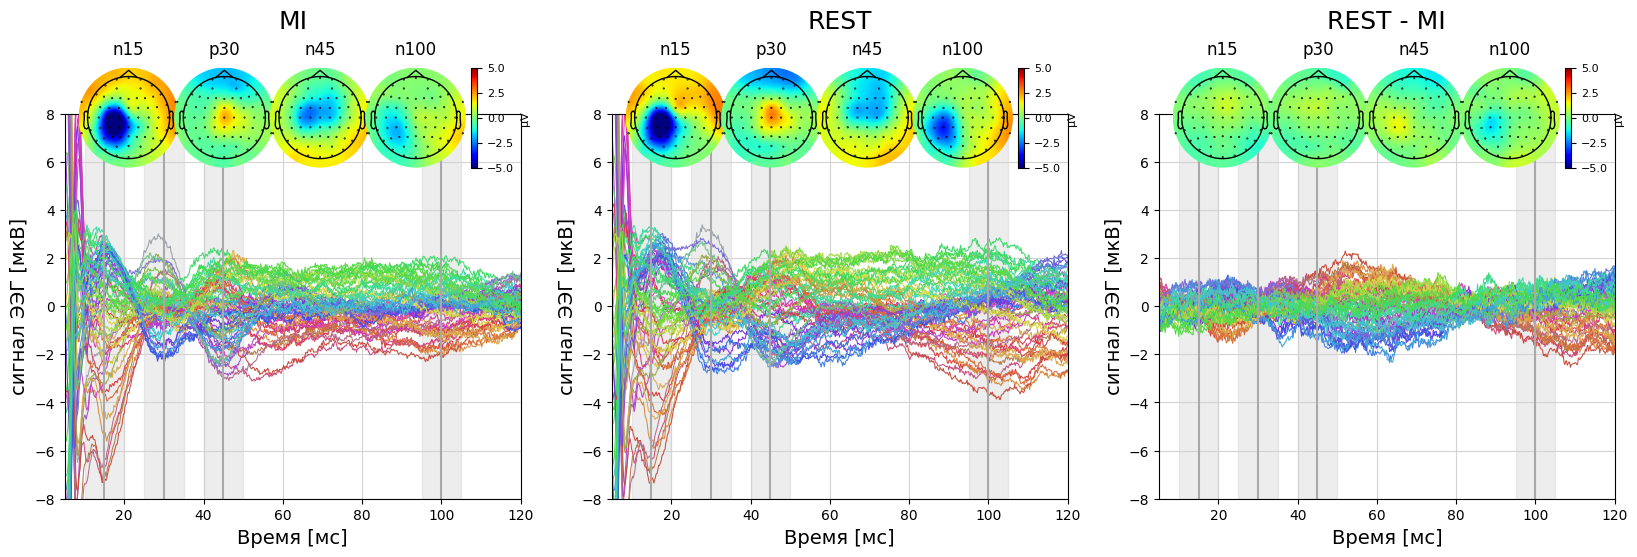

In [137]:
def plot_TEPs_with_topo(ax, TEPs, tmin=5, tmax=120, amp=10, comps = [15, 30, 45, 100]):

    comp_names = ["n15", "p30", "n45", "n100"]
    topo_windows = [(10, 25), (20, 40), (40, 55), (80, 120)]

    for color, TEP in zip(colors, TEPs): # начало движения
        ax.plot(tvec, TEP, color=color, linewidth=.75)
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    ax.set_xlabel("Время [мс]", fontsize=14)
    ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
    ax.grid(color="lightgrey")
    ax.axvline(0, color="black", linewidth=2)

    topo_size = 0.26
    topo_y = 0.86
    topo_xs = np.linspace(0.01, 0.64, len(topo_windows))

    t = tmin
    def get_mask(tlim, tvec):
        return np.where((tvec >= tlim[0]) & (tvec <= tlim[1]))[0]

    for topo_x, tlim, comp,name in zip(topo_xs, topo_windows, comps,comp_names):
        time_mask = get_mask([comp-5, comp+5], tvec)
        TEPs_topo = np.mean(TEPs[:, time_mask], axis=1)

        topo_ax = ax.inset_axes([topo_x, topo_y, topo_size, topo_size])
        max_value = 5
        im, _ = plot_topomap(
            TEPs_topo,
            positions,
            axes=topo_ax,
            ch_type="eeg",
            image_interp="cubic",
            size=5,
            show=False,
            contours=0,
            sphere=0.55,
            cmap="jet",
            extrapolate="head",
            vlim=(-max_value, max_value),
        )
        topo_ax.set_title(name, fontsize=12, y=1.05)

        ax.axvline(comp, color="darkgrey")
        a = 0.2
        ax.axvspan(comp-5, comp+5, alpha=a, color='darkgrey', zorder=1)

    cbar_ax = ax.inset_axes([0.89, topo_y, 0.015, topo_size])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label("μV", fontsize=8)
    cbar.ax.tick_params(labelsize=8)

fig, axis = plt.subplots(1, 3, figsize=(20, 5))
for ax, TEPs in zip(axis, [TEPs_MI_mean, TEPs_rest_mean, TEPs_rest_mean - TEPs_MI_mean]):
    plot_TEPs_with_topo(ax, TEPs, amp=8)

axis[0].set_title('MI', fontsize=18, y=1.2)
axis[1].set_title('REST', fontsize=18, y=1.2)
axis[2].set_title('REST - MI', fontsize=18, y=1.2)

In [145]:
filename = r"../../data/exp/offBCI.xlsx"
df = pd.read_excel(filename)
df.head()

,subject,power,cond,N15-lat,N15-amp,P30-lat,P30-amp,N45-lat,N45-amp,N100-lat,N100-amp,orientation
0,01AV,42,MI,18.0,-4.0,26.0,1.5,43.0,-4.5,88.0,-3.5,AP
1,01AV,42,rest,18.0,-2.5,27.0,5.0,46.0,-4.0,102.0,-8.5,AP
2,02NS,54,MI,15.0,-24.0,NaN,NaN,41.0,-7.0,60.0,-7.0,AP
3,02NS,54,rest,15.0,-25.0,NaN,NaN,44.0,-7.0,70.0,-4.0,AP
4,04KK,36,MI,14.0,-5.0,27.0,3.5,43.0,-3.0,60.0,-9.5,PA


In [135]:
TEPs_MI.shape

(10, 64, 4001)

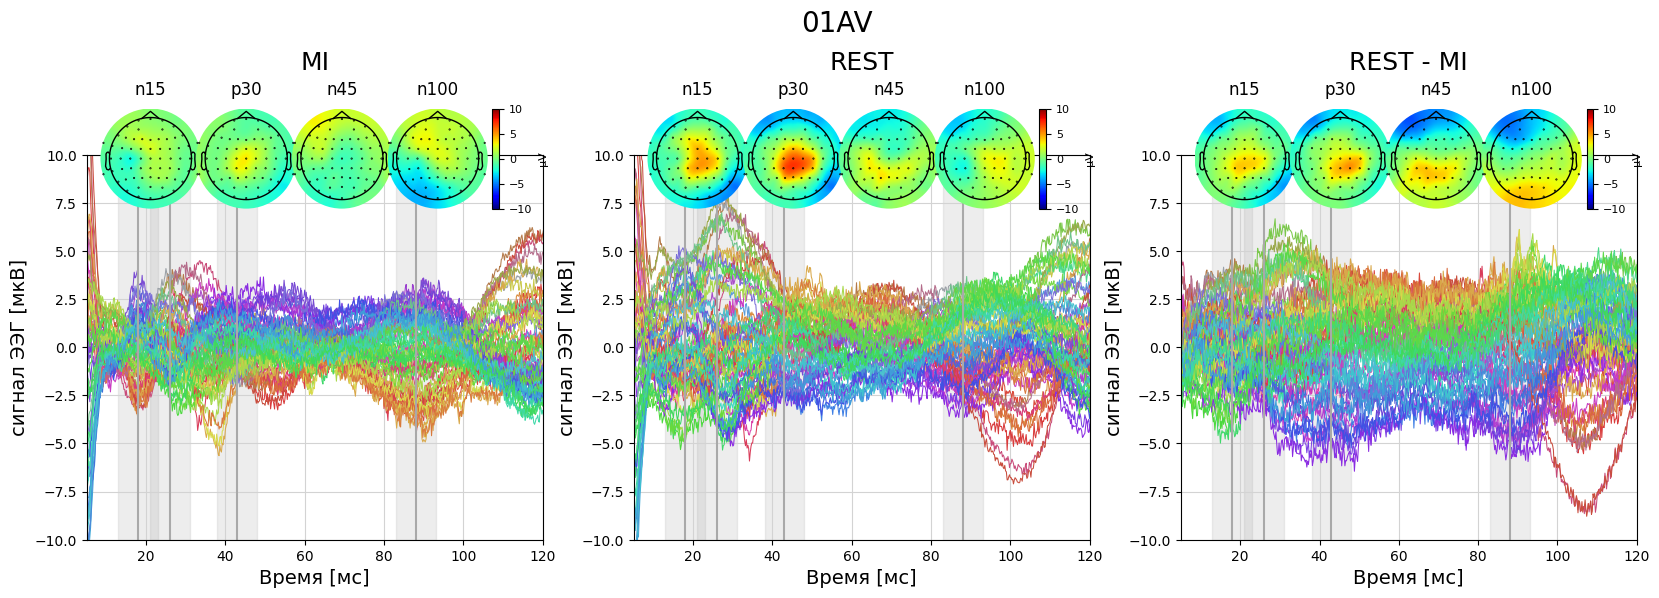

In [136]:
for i in range(len(TEPs_MI)):
    TEPs_MI_subj = TEPs_MI[i]
    TEPs_rest_subj = TEPs_rest[i]
    subject = list(session_dict.keys())[i+1]
    comps = df.loc[(df.subject ==subject) & (df.cond=="MI")][["N15-lat", "P30-lat", "N45-lat", "N100-lat"]].values[0]

    fig, axis = plt.subplots(1, 3, figsize=(20, 5))
    for ax, TEPs in zip(axis, [TEPs_MI_subj, TEPs_rest_subj, TEPs_rest_subj - TEPs_MI_subj]):
        plot_TEPs_with_topo(ax, TEPs, amp=10, comps=comps)

    axis[0].set_title('MI', fontsize=18, y=1.2)
    axis[1].set_title('REST', fontsize=18, y=1.2)
    axis[2].set_title('REST - MI', fontsize=18, y=1.2)

    fig.suptitle(subject, y=1.17, fontsize=20)
    plt.show()
    break

In [195]:
df = df.loc[(df.subject != "18EK") & (df.subject != "09TI")]
df

,subject,power,cond,N15-lat,N15-amp,P30-lat,P30-amp,N45-lat,N45-amp,N100-lat,N100-amp,orientation
0,01AV,42,MI,18.0,-4.0,26.0,1.5,43.0,-4.5,88.0,-3.5,AP
1,01AV,42,rest,18.0,-2.5,27.0,5.0,46.0,-4.0,102.0,-8.5,AP
2,02NS,54,MI,15.0,-24.0,NaN,NaN,41.0,-7.0,60.0,-7.0,AP
3,02NS,54,rest,15.0,-25.0,NaN,NaN,44.0,-7.0,70.0,-4.0,AP
4,04KK,36,MI,14.0,-5.0,27.0,3.5,43.0,-3.0,60.0,-9.5,PA
5,04KK,36,rest,14.0,-5.0,27.0,2.0,45.0,-3.5,64.0,-8.0,PA
6,05UB,36,MI,11.0,-4.0,29.0,3.0,47.0,-2.0,NaN,NaN,AP
7,05UB,36,rest,11.0,-1.5,29.0,3.0,48.0,-3.0,NaN,NaN,AP
8,07IK,50,MI,15.0,-8.0,30.0,5.5,NaN,NaN,107.0,-10.0,AP
9,07IK,50,rest,16.0,-13.0,30.0,6.0,NaN,NaN,117.0,-14.0,AP


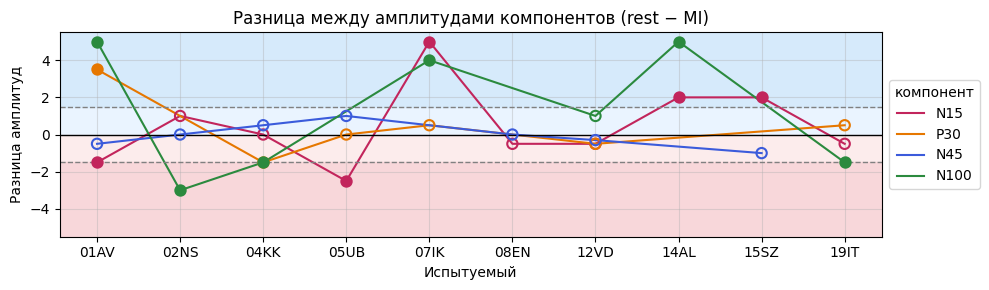

In [313]:
diffs = []

components = ["N15-amp", "P30-amp", "N45-amp", "N100-amp"]

for subj in df.subject.unique():
    comps = np.abs(
        df.loc[df.subject == subj, components].values
    )

    values = np.diff(comps, axis=0)[0]

    diffs.append({
        "subject": subj,
        "N15-amp": values[0],
        "P30-amp": values[1],
        "N45-amp": values[2],
        "N100-amp": values[3]
    })

df_diffs = pd.DataFrame(diffs)

fig, ax = plt.subplots(figsize=(10, 3))

palette = [
    "#C2255C",  # малиновый
    "#E67700",  # янтарный
    "#3B5BDB",  # индиго
  "#2B8A3E",  # изумрудный
]

min_diff = 1.5
maxvalue = 5.5
for i, comp in enumerate(components):
    color = palette[i]

    # Убираем NaN
    valid = df_diffs[["subject", comp]].dropna()

    # Линия через все существующие точки
    ax.plot(
        valid["subject"],
        valid[comp],
        color=color,
        linewidth=1.5,
        label=comp.split("-")[0],
        zorder=2
    )

    values = df_diffs[comp]

    inside = (values.abs() < min_diff) & values.notna()
    outside = (values.abs() >= min_diff) & values.notna()

    # Незакрашенные точки
    ax.scatter(
        df_diffs.loc[inside, "subject"],
        values.loc[inside],
        facecolors="none",
        edgecolors=color,
        linewidths=1.5,
        s=55,
        zorder=3
    )

    # Закрашенные точки
    ax.scatter(
        df_diffs.loc[outside, "subject"],
        values.loc[outside],
        facecolors=color,
        edgecolors=color,
        linewidths=1.5,
        s=55,
        zorder=3
    )

ax.grid(alpha=0.4)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    title="компонент"
)

ax.axhline(0, color="black", linewidth=1)

positive = "#EAF4FF"
positive_strong = "#D6EAFB"
negative = "#FCECEC"
negative_strong = "#F8D7DA"

# Общий фон для положительных и отрицательных значений
ax.axhspan(0, min_diff, color=positive, alpha=1)
ax.axhspan(-min_diff, 0, color=negative, alpha=1)

# Области значимых различий
ax.axhspan(min_diff, maxvalue, color=positive_strong, alpha=1)
ax.axhspan(-maxvalue, -min_diff, color=negative_strong, alpha=1)

# Границы порогового диапазона
ax.axhline(min_diff, color="gray", linestyle="--", linewidth=1)
ax.axhline(-min_diff, color="gray", linestyle="--", linewidth=1)

ax.set_ylim(-maxvalue, maxvalue)
ax.set_ylabel("Разница амплитуд")
ax.set_xlabel("Испытуемый")
ax.set_title("Разница между амплитудами компонентов (rest − MI)")

plt.tight_layout()
plt.show()

          N100-amp   N45-amp
N100-amp  1.000000 -0.413049
N45-amp  -0.413049  1.000000


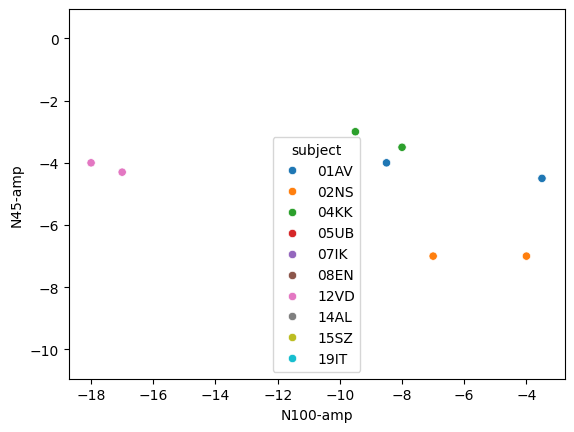

In [309]:
sns.scatterplot(df, x="N100-amp", y="N45-amp", hue="subject")
plt.axis("equal")
r = df[["N100-amp", "N45-amp"]].corr(method="pearson")
print(r)

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
[-1.5, 3.5, -0.5, 5.0, -1.5]
[1.0, nan, 0.0, -3.0, 1.0]
[0.0, -1.5, 0.5, -1.5, 0.0]
[-2.5, 0.0, 1.0, nan, -2.5]
[5.0, 0.5, nan, 4.0, 5.0]
[-0.5, nan, 0.0, nan, -0.5]
[-0.5, -0.5, -0.2999999999999998, 1.0, -0.5]
[2.0, nan, nan, 5.0, 2.0]
[2.0, nan, -1.0, nan, 2.0]
[-0.5, 0.5, nan, -1.5, -0.5]


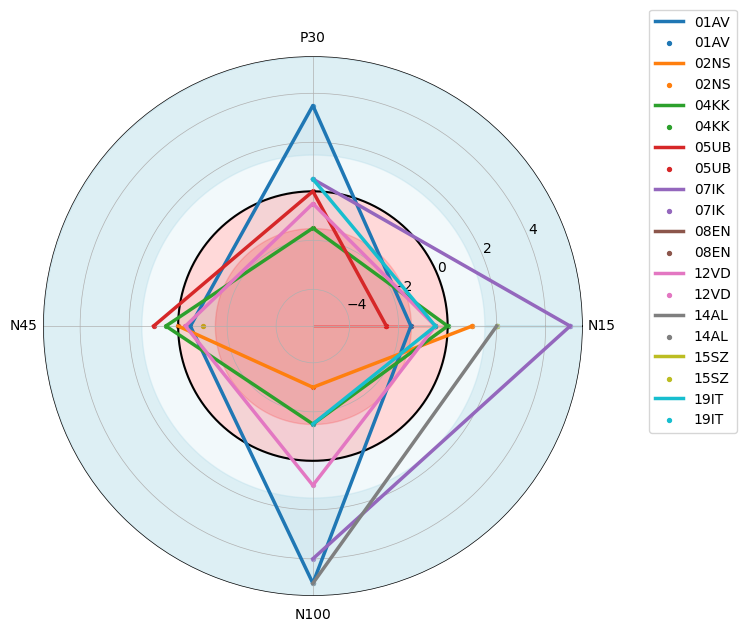

In [233]:

# Названия осей
labels = ["N15", "P30", "N45", "N100"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
print(colors)

diffs = []
for subj in df.subject.unique():
    comps = np.abs(df.loc[df.subject == subj][["N15-amp", "P30-amp", "N45-amp", "N100-amp"]].values)
    values = np.diff(comps, axis=0)[0]
    diffs.append(values)
data = np.array(diffs)

n_vars = len(labels)

# Углы осей
angles = np.linspace(0, 2*np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]  # замыкаем круг

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

theta = np.linspace(0, 2*np.pi, 300)
ax.plot(theta, np.full_like(theta, 0.), color='black', lw=1.5)


ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.grid(linewidth=0.5)
ax.spines['polar'].set_linewidth(0.5)

for i, subject in enumerate(data):
    values = subject.tolist()
    values += values[:1]      # замыкаем контур
    ax.plot(angles, values, linewidth=2.5, label=df.subject.unique()[i], color=colors[i]) #, color="darkgrey")
    ax.scatter(angles, values, s=8,  label=df.subject.unique()[i], color=colors[i]) #, color="darkgrey")
    print(values)
    ax.fill(angles, values, alpha=0.05)


max_value = 5
min_diff = 1.5
ax.fill_between(theta, -max_value-.5, 0, alpha=0.15, color='red')
ax.fill_between(theta, -max_value-.5, -min_diff, alpha=0.15, color='red')
ax.fill_between(theta, 0, max_value+.5, alpha=0.15, color='lightblue')
ax.fill_between(theta, min_diff, max_value+.5, alpha=0.3, color='lightblue')
# ax.fill_between(theta, -min_diff, min_diff, alpha=0.3, color="grey")

ax.set_ylim(-max_value-.5, max_value+.5)

plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

In [156]:
data

array([[  1.5,   3.5,   0.5,  -5. ],
       [-21.5,   nan,  -3. ,   1.5],
       [ -1. ,   nan,   0. ,   3. ],
       [ 20. ,   nan,   4. ,  -5.5],
       [  0. ,  -1.5,  -0.5,   1.5],
       [  1. ,   1. ,   1.5,   nan],
       [  2.5,   0. ,  -1. ,   nan],
       [ -6.5,   2.5,   nan,   nan],
       [ -5. ,   0.5,   nan,  -4. ],
       [  8.5,   nan,   nan,   nan],
       [  0.5,   nan,   0. ,   nan],
       [  nan,   nan,   nan,   nan]])

array([[-1.0164816 , -1.1182702 , -1.4512653 , ..., -2.2898989 ,
        -2.0419455 , -2.2170131 ],
       [ 0.03902872,  0.30590597, -0.0237829 , ..., -0.42221355,
         0.25884664,  0.20264116],
       [-2.1251705 , -1.6484436 , -1.8587584 , ..., -1.037301  ,
        -1.1087034 , -0.69474864],
       ...,
       [ 1.1213586 ,  1.3367352 ,  1.1695477 , ...,  2.7718818 ,
         2.8104908 ,  2.66249   ],
       [ 1.0612413 ,  1.1777469 ,  1.034897  , ...,  1.7384568 ,
         2.0556595 ,  2.040274  ],
       [ 1.9076903 ,  1.9362115 ,  1.9892918 , ...,  1.0620621 ,
         1.6012797 ,  1.5909659 ]], shape=(64, 4001), dtype=float32)

In [21]:
n20 = (10, 25)
p30 = (20, 40)
n45 = (30, 50)
p60 = (55, 75)
n100 = (70, 120)
comps = [n20, p30, n45, p60, n100]

from scipy.signal import find_peaks

In [ ]:
for TEP in TEPs_mi:
    curr_TEP = TEP[]
    print(find_peaks(TEP))

(array([   2,    5,   11, ..., 3991, 3993, 3998], shape=(1227,)), {})
(array([   5,    8,   12, ..., 3986, 3992, 3995], shape=(1034,)), {})
(array([   2,    4,    6, ..., 3991, 3997, 3999], shape=(1223,)), {})
(array([   2,    5,    9, ..., 3991, 3994, 3998], shape=(1228,)), {})
(array([   2,    4,   12, ..., 3993, 3995, 3998], shape=(1161,)), {})
(array([   2,    4,    7, ..., 3991, 3994, 3997], shape=(1202,)), {})
(array([   2,    5,    7, ..., 3990, 3993, 3996], shape=(1245,)), {})
(array([   1,    6,    9, ..., 3988, 3994, 3998], shape=(1264,)), {})
(array([   3,    5,    8, ..., 3992, 3995, 3999], shape=(1228,)), {})
(array([   2,    4,    8, ..., 3993, 3996, 3998], shape=(1241,)), {})
(array([   2,    6,   11, ..., 3992, 3996, 3998], shape=(1242,)), {})
(array([   5,    8,   11, ..., 3995, 3997, 3999], shape=(1173,)), {})
(array([   1,    5,    8, ..., 3993, 3995, 3998], shape=(1214,)), {})
(array([   4,    8,   10, ..., 3993, 3996, 3998], shape=(1247,)), {})
(array([   3,    6, 